## FDTD for Room Acoustics, Part 2: Implementing the 2D FDTD Scheme in Dr.Jit

### Implementation using Dr.Jit in Python 

For the implementation of the FDTD update formula for the wave equation we derived in Part 1 of this series, we will use Dr.Jit, a Python library for writing parallel programs that can run on the CPU or GPU. It also supports automatic differentiation, which makes it interesting for optimization problems.

Wave-based acoustic solvers are computationally intensive, so parallelisation is essential for acceptable performance at larger scales. The differentiability of Dr.Jit also opens up interesting possibilities: instead of only simulating a given scene, we can later ask how a scene or an initial condition would have to change in order to produce a desired acoustic result.

Compared with writing kernels directly in CUDA, Dr.Jit lets us write the program at a higher level. It then converts parts of the program into parallel kernels just in time and runs them on the selected hardware.

In the first part of the code we are dealing with library imports and check what backend and version dr.jit is using. The debugging flag can be very helpful in case we are running into trouble. 

In [1]:
#import libraries
import drjit as dr
from drjit.cuda import Float, UInt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

# print the dr.jit backend
print("backend:", dr.backend_v(Float),"version:", dr.__version__)

# helpful for debugging
dr.set_flag(dr.JitFlag.Debug, True)

backend: JitBackend.CUDA version: 1.0.5


In our first function we define a spatial Gaussian initial pressure/displacement field in the center of the domain. For each grid point, we compute the squared distance $ r^2 $ from the domain midpoint and evaluate a Gaussian profile. The parameter $ \sigma $ controls the spatial width of the bump; here it is set to $ 3\% $ of the smaller domain dimension so that the source remains compact even for rectangular domains. 

$$ \begin{align} u_0(x,y) &= \exp \left (-\frac{ (x - x_0 ) ^2 + ( y - y_0) ^2 }{2 \sigma ^2} \right) \\ &= \exp\left(-\frac{r ^ 2}{2\sigma ^ 2}\right) \end{align} \tag{2} $$

The purpose of this function is not to model a physical loudspeaker yet. It simply creates a smooth, localized disturbance so that the finite-difference scheme has something to propagate.


In [2]:
#function for gaussian impulse in the middle of the domain
def gaussian(xL,xR,yB,yT,dx,dy,iy,jx):
    
    # coordinates of the grid nodes
    x = xL + Float(jx) * dx
    y = yB + Float(iy) * dy
    
    # define center of physical domain
    x0, y0 = 0.5*(xL+xR), 0.5*(yB+yT)
    
    # set inital width of the gaussian
    sigma = 0.03 * min(xR-xL, yT-yB)
    
    # compute a squared distance from the domain center
    r2 = (x-x0)*(x-x0) + (y-y0)*(y-y0)
    
    # compute initial Gaussian (negative exponential function)
    # at domain center r2 will be zero, the exponential 1. 
    u0 = dr.exp(-r2 / (2.0 * sigma * sigma))
    
    return u0

Now we get to the actual main function `run_sim_frames`. A detailed description in sections can be found in the accompanying blog post.

In [3]:
def run_sim_frames(nx=131, ny=66, xL=0.0, xR=2.0, yB=0.0, yT=1.0,
                   c=343.0, te=0.0003, cfl_scale=0.9, record_every=2,source="gaussian"):
    
    # total number of gridpoints
    N = nx * ny
    # physical grid spacing in x and y direction
    dx = (xR - xL) / (nx - 1)
    dy = (yT - yB) / (ny - 1)

    # compute the maximum stable timestep from the 2D CFL condition (see also equation 2)
    dt_max = 1.0 / (c * dr.sqrt(1.0/(dx*dx) + 1.0/(dy*dy)))
    # multiply by a safety factor below one
    dt = cfl_scale * dt_max
    nsteps = int(te / dt)

    # express grid indices using a 1d jit array
    k  = dr.arange(UInt, N)
    # row indices in y, e.g. for nx=2, ny=3 -> [0, 0, 1, 1, 2, 2] 
    iy = k // nx
    # column indices in x, e.g. for nx=2, ny=3 -> [0, 1, 0, 1, 0, 1]
    jx = k - iy * nx

    # define boolean mask for interior nodes
    is_interior = (iy > 0) & (iy < ny - 1) & (jx > 0) & (jx < nx - 1)

    # get index offsets for stencil (left, right, bottom and top)
    # border indices are clamped. This is harmless here because
    # the update is later masked so that boundary nodes remain zero.
    jxL = dr.select(jx > 0,      jx - 1, jx)
    jxR = dr.select(jx + 1 < nx, jx + 1, jx)
    iyB = dr.select(iy > 0,      iy - 1, iy)
    iyT = dr.select(iy + 1 < ny, iy + 1, iy)

    # get left, right, top and bottom neighbour for every stencil center
    idxL = iy * nx + jxL
    idxR = iy * nx + jxR
    idxB = iyB * nx + jx
    idxT = iyT * nx + jx

    # arrays for pressure fields at previous, current and next timestep
    u_prev = dr.zeros(Float, N)
    u_cur  = dr.zeros(Float, N)
    u_next = dr.zeros(Float, N)

    # initialise the current pressure field with a centered Gaussian bump
    if source == "gaussian":
        init = gaussian(xL,xR,yB,yT,dx,dy,iy,jx)
        
        # initialise current field interior with gaussian, boundary zero
        u_cur = dr.select(is_interior, init, 0.0)

        # create detached copy for previous timestep
        u_prev = dr.detach(u_cur)

    # placeholder for other sourcetypes
    # elif source == "placeholder":
    
    else:
        print('No valid sourcename provided')

    # initialise output frames in numpy
    frames = [np.array(u_cur, dtype=np.float32).reshape(ny, nx)] 

    # the fractions from the cfl condition in x and y direction
    cx2 = (c * dt / dx) ** 2
    cy2 = (c * dt / dy) ** 2

    # loop over n timesteps
    for t in range(nsteps):

        # previous time level at each stencil center
        up = u_prev
        
        # gather the five-point stencil at the current time level:
        # center, left, right, bottom, top
        uc = u_cur
        ul = dr.gather(Float, u_cur, idxL)
        ur = dr.gather(Float, u_cur, idxR)
        ub = dr.gather(Float, u_cur, idxB)
        ut = dr.gather(Float, u_cur, idxT)

        # calculate next timestep centerpoint (see also equation 1)
        un = 2.0*uc - up + cx2*(ul - 2.0*uc + ur) + cy2*(ub - 2.0*uc + ut)

        # apply boundary condition by masking, no scatter needed
        u_next = dr.select(is_interior, un, 0.0)

        # rotate buffers
        u_prev, u_cur = u_cur, u_next

        if (t + 1) % record_every == 0:
            # each recorded frame forces evaluation and copies data from device/JIT memory to NumPy
            frames.append(np.array(u_cur, dtype=np.float32).reshape(ny, nx))

    return np.stack(frames), dt, nsteps

### Calling the simulation ###

In [ ]:
xL_s, xR_s = 0.0, 2.0
yB_s, yT_s = 0.0, 1.0   # rectangle if you want
frames, dt, nsteps = run_sim_frames(xL=xL_s, xR=xR_s, yB=yB_s, yT=yT_s, nx=200, ny=100, te=0.012, source="gaussian")

print("frames:", frames.shape)
print("mean |delta| between frames:", np.mean(np.abs(np.diff(frames, axis=0))))

frames: (160, 50, 100)
mean |delta| between frames: 0.014464913


### Visualisation ###

For visualization, we fix a symmetric colour scale around zero. The value v is chosen from a high quantile of the absolute field values, which avoids a few extreme values dominating the colour range. TwoSlopeNorm then maps negative and positive values symmetrically around zero, so that blue and red represent waves of opposite sign.  Let's first plot the last frame of our simulation with following code for a first inspection. 

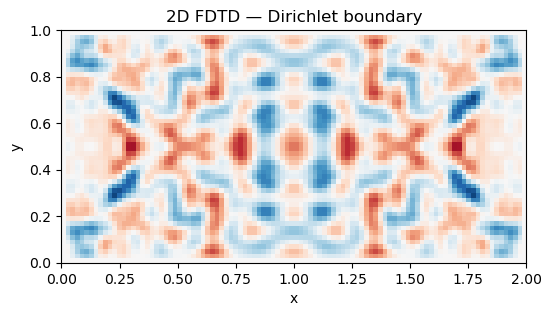

In [5]:
# center colormap at 0 so positives/negatives are balanced
v = np.quantile(np.abs(frames), 0.995)
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

fig, ax = plt.subplots(figsize=(6,3.6))
im = ax.imshow(frames[-5], origin="lower", cmap="RdBu_r", norm=norm, extent=[xL_s, xR_s, yB_s, yT_s])
ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("2D FDTD — Dirichlet boundary")
plt.show()

### Save animation ###
Finally we can create an animation by calling above plot function for every output frame and saving it to disk. For short animations gifs are fine, but for longer ones compressed video files are the better choice. We stick for now with gifs. 

In [ ]:
def update(i):
    im.set_data(frames[i])
    return (im,)

gifname = "part02_fdtd_2d_drjit_dirichlet.gif"
outdir = Path("../outputs")
outdir.mkdir(exist_ok=True)

gifpath = outdir / gifname

ani = FuncAnimation(fig, update, frames=frames.shape[0], interval=40, blit=False)
ani.save(gifpath, writer=PillowWriter(fps=25))
plt.close(fig)

print(rf"saved {gifpath}")